In [1]:
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma

In [2]:
%load_ext autoreload
%autoreload 1
%aimport crossmatching
from crossmatching import Crossmatcher


In [3]:
cm = Crossmatcher()
cm.load_catalog(from_file="pscomppars.txt")
input_t = ascii.read("./input/HPIC_LC4_combined_d50.txt")
name_list = input_t["star_name"]  
_ = cm.load_alternate_ids(name_list, from_file="alternate_ids.txt")

In [4]:
set(cm.coordinate_crossmatch(input_t)[0].keys()) - set(cm.coordinate_crossmatch(input_t)[1].keys())
# yay 

{'3d_sep'}

In [5]:
set(cm.coordinate_crossmatch(input_t)[0].keys()) - set(cm.id_crossmatch(input_t).keys())

{'3d_sep'}

In [6]:
set(cm.id_crossmatch(input_t).keys()) - set(cm.coordinate_crossmatch(input_t)[0].keys())

{'id', 'input_ids'}

In [7]:
cm.combined_crossmatch(input_t)

star_name,sy_dist_input,st_spectype_input,st_rad_input,st_teff_input,st_mass_input,st_age_input,ra_input,dec_input,sy_vmag_input,sy_jmag_input,sy_hmag_input,sy_kmag_input,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,disc_method,discoverymethod,disc_locale,disc_facility,disc_instrument,disc_telescope,disc_refname,ra_cat,raerr1,raerr2,rasymerr,rastr,ra_solnid,ra_reflink,dec_cat,decerr1,decerr2,decsymerr,decstr,dec_solnid,dec_reflink,glon,glonerr1,glonerr2,glonsymerr,glonstr,glon_solnid,glon_reflink,glat,glaterr1,glaterr2,glatsymerr,glatstr,glat_solnid,glat_reflink,elon,elonerr1,elonerr2,elonsymerr,elonstr,elon_solnid,elon_reflink,elat,elaterr1,elaterr2,elatsymerr,elat_solnid,elat_reflink,elatstr,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbpersymerr,pl_orbperlim,pl_orbperstr,pl_orbperformat,pl_orbper_solnid,pl_orbper_reflink,pl_orblpererr1,pl_orblper,pl_orblpererr2,pl_orblpersymerr,pl_orblperlim,pl_orblperstr,pl_orblperformat,pl_orblper_solnid,pl_orblper_reflink,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxsymerr,pl_orbsmaxlim,pl_orbsmaxstr,pl_orbsmaxformat,pl_orbsmax_solnid,pl_orbsmax_reflink,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbinclsymerr,pl_orbincllim,pl_orbinclstr,pl_orbinclformat,pl_orbincl_solnid,pl_orbincl_reflink,pl_orbtper,pl_orbtpererr1,pl_orbtpererr2,pl_orbtpersymerr,pl_orbtperlim,pl_orbtperstr,pl_orbtperformat,pl_orbtper_solnid,pl_orbtper_reflink,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccensymerr,pl_orbeccenlim,pl_orbeccenstr,pl_orbeccenformat,pl_orbeccen_solnid,pl_orbeccen_reflink,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtsymerr,pl_eqtlim,pl_eqtstr,pl_eqtformat,pl_eqt_solnid,pl_eqt_reflink,pl_occdep,pl_occdeperr1,pl_occdeperr2,pl_occdepsymerr,pl_occdeplim,pl_occdepstr,pl_occdepformat,pl_occdep_solnid,pl_occdep_reflink,pl_insol,pl_insolerr1,pl_insolerr2,pl_insolsymerr,pl_insollim,pl_insolstr,pl_insolformat,pl_insol_solnid,pl_insol_reflink,pl_dens,pl_denserr1,sy_umagerr1,sy_umagerr2,sy_umaglim,sy_umagsymerr,sy_umagstr,sy_umagformat,sy_umag_solnid,sy_umag_reflink,sy_rmag,sy_rmagerr1,sy_rmagerr2,sy_rmaglim,sy_rmagsymerr,sy_rmagstr,sy_rmagformat,sy_rmag_solnid,sy_rmag_reflink,sy_imag,sy_imagerr1,sy_imagerr2,sy_imaglim,sy_imagsymerr,sy_imagstr,sy_imagformat,sy_imag_solnid,sy_imag_reflink,sy_zmag,sy_zmagerr1,sy_zmagerr2,sy_zmaglim,sy_zmagsymerr,sy_zmagstr,sy_zmagformat,sy_zmag_solnid,sy_zmag_reflink,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w1maglim,sy_w1magsymerr,sy_w1magstr,sy_w1magformat,sy_w1mag_solnid,sy_w1mag_reflink,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w2maglim,sy_w2magsymerr,sy_w2magstr,sy_w2magformat,sy_w2mag_solnid,sy_w2mag_reflink,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w3maglim,sy_w3magsymerr,sy_w3magstr,sy_w3magformat,sy_w3mag_solnid,sy_w3mag_reflink,sy_w4mag,sy_w4magerr1,sy_w4magerr2,sy_w4maglim,sy_w4magsymerr,sy_w4magstr,sy_w4magformat,sy_w4mag_solnid,sy_w4mag_reflink,sy_gmag,sy_gmagerr1,sy_gmagerr2,sy_gmaglim,sy_gmagsymerr,sy_gmagstr,sy_gmagformat,sy_gmag_solnid,sy_gmag_reflink,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_gaiamaglim,sy_gaiamagsymerr,sy_gaiamagstr,sy_gaiamagformat,sy_gaiamag_solnid,sy_gaiamag_reflink,sy_tmag,sy_tmagerr1,sy_tmagerr2,sy_tmaglim,sy_tmagsymerr,sy_tmagstr,sy_tmagformat,sy_tmag_solnid,sy_tmag_reflink,sy_name,pl_controv_flag,pl_orbtper_systemref,pl_tranmid_systemref,st_metratio,st_spectype_cat,st_spectype_solnid,st_spectype_reflink,sy_plxlim,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,sy_kepmaglim,sy_kepmagsymerr,sy_kepmagstr,sy_kepformat,sy_kepmag_solnid,sy_kepmag_reflink,st_rotp,st_rotperr1,st_rotperr2,st_rotpsymerr,st_rotplim,st_rotpstr,st_rotpformat,st_rotp_solnid,st_rotp_reflink,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_projobliqsymerr,pl_projobliqlim,pl_projobliqstr,pl_projobliqformat,pl_denserr2,pl_denssymerr,pl_denslim,pl_densstr,pl_densformat,pl_dens_solnid,pl_dens_reflink,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_trandepsymerr,pl_trandeplim,pl_trandepstr,pl_tra

In [8]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
# good this means that every planet is unique
print(len(set(cm.id_matched["star_name"])))  
print(len(set(cm.id_matched["hostname"])))
print(len(input_t), len(set(input_t["star_name"])))
# alright input contains a duplicate
# so in short, we expect a lot of systmes to be matched with multiple planets

473 477
302
301
14571 14570


In [9]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
print(len(input_t), len(set(input_t["star_name"])))
# planets 

473 477
14571 14570


In [10]:
len(cm.matched)

852

In [11]:
Counter(cm.matched["match_type"])

Counter({np.str_('id'): 477, np.str_('2d'): 293, np.str_('3d'): 82})

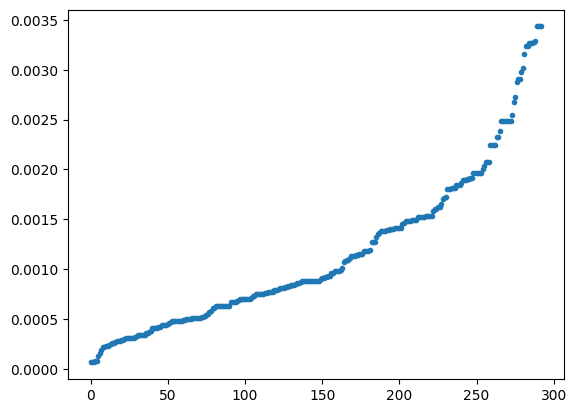

In [12]:
plt.plot(np.sort(cm.matched["2d_sep"]), '.')

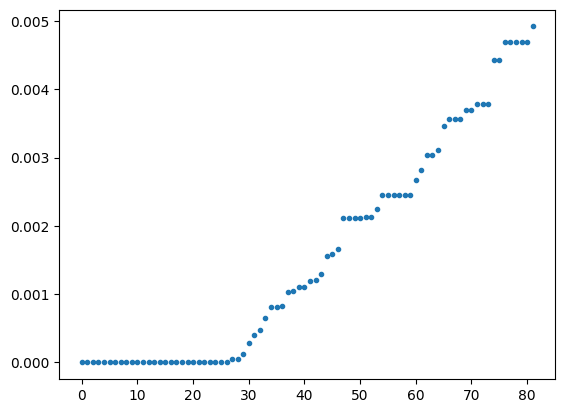

In [13]:
plt.plot(np.sort(cm.matched["3d_sep"]), '.')

In [14]:
Counter(cm.catalogue["pl_name"])

Counter({np.str_('Kepler-1167 b'): 1,
         np.str_('Kepler-1740 b'): 1,
         np.str_('Kepler-1581 b'): 1,
         np.str_('Kepler-644 b'): 1,
         np.str_('Kepler-1752 b'): 1,
         np.str_('Kepler-280 c'): 1,
         np.str_('Kepler-1208 b'): 1,
         np.str_('Kepler-263 c'): 1,
         np.str_('Kepler-1101 b'): 1,
         np.str_('HD 168746 b'): 1,
         np.str_('K2-19 b'): 1,
         np.str_('Kepler-560 b'): 1,
         np.str_('Kepler-150 d'): 1,
         np.str_('Kepler-498 b'): 1,
         np.str_('Kepler-817 b'): 1,
         np.str_('Kepler-937 b'): 1,
         np.str_('K2-10 b'): 1,
         np.str_('Kepler-571 b'): 1,
         np.str_('Kepler-1458 b'): 1,
         np.str_('K2-335 b'): 1,
         np.str_('Kepler-1600 c'): 1,
         np.str_('Kepler-221 d'): 1,
         np.str_('Kepler-626 b'): 1,
         np.str_('Kepler-1549 b'): 1,
         np.str_('K2-62 c'): 1,
         np.str_('Kepler-1149 b'): 1,
         np.str_('Kepler-1288 b'): 1,
         n

In [15]:
final = cm.combined_crossmatch(input_t)
print(len(cm.id_matched))
print(len(cm.coords3d_matched))
print(len(cm.coords2d_matched))
print(Counter(final["match_type"]))
print(len(final), len(set(final["pl_name"]))) # this shouldn't happen
# final["pl_name", "match_type"]].to_pandas().sort_values("pl_name").to_csv("final_crossmatch.csv", index=False)
# final["pl_name", "match_type"].to_pandas().groupby("pl_name").count().sort_values("match_type", ascending=False)
final["pl_name", "star_name", "hostname", "id", "match_type"][np.isin(final["pl_name"], ["HD 46375 b", "DS Tuc A b",  "GJ 887 b", "GJ 887 c", "GJ 887 d"])]
# we conclude that the combination might work, but both methods can produce duplicates, need to further investigate why

477
184
727
Counter({np.str_('id'): 477, np.str_('2d'): 293, np.str_('3d'): 82})
852 848


pl_name,star_name,hostname,id,match_type
str29,str29,str27,str23,str2
GJ 887 b,TIC 471015557,GJ 887,GJ 887,id
GJ 887 b,TIC 155315739,GJ 887,GJ 887,id
GJ 887 c,TIC 471015557,GJ 887,GJ 887,id
GJ 887 c,TIC 155315739,GJ 887,GJ 887,id
GJ 887 d,TIC 471015557,GJ 887,GJ 887,id
GJ 887 d,TIC 155315739,GJ 887,GJ 887,id
HD 46375 b,TIC 234928947,HD 46375,--,2d
DS Tuc A b,TIC 410214986,DS Tuc A,--,2d


In [16]:
Counter(cm.alternate_ids["id"].data.data)

Counter({np.str_('0'): 815,
         np.str_('1RXS J230547.3-355125'): 2,
         np.str_('TYC 7512-1263-1'): 2,
         np.str_('TIC 471015557'): 2,
         np.str_('TIC 155315739'): 2,
         np.str_('GJ 887'): 2,
         np.str_('Gaia DR3 6553614253923452800'): 2,
         np.str_('GC 32159'): 2,
         np.str_('UGP 591'): 2,
         np.str_('2MASS J23055131-3551130'): 2,
         np.str_('PLX 5584'): 2,
         np.str_('CNS5 5688'): 2,
         np.str_('AC2000 3355101'): 2,
         np.str_('CD-36 15693'): 2,
         np.str_('CPC 18 11792'): 2,
         np.str_('CPD-36  9694'): 2,
         np.str_('CSV   8819'): 2,
         np.str_('Ci 20 1400'): 2,
         np.str_('GCRV 14482'): 2,
         np.str_('GEN# +1.00217987'): 2,
         np.str_('HD 217987'): 2,
         np.str_('HIC 114046'): 2,
         np.str_('HIP 114046'): 2,
         np.str_('IRAS 23029-3607'): 2,
         np.str_('JP11  3579'): 2,
         np.str_('LFT 1758'): 2,
         np.str_('LHS    70'): 2,
     

In [17]:
cm.alternate_ids[cm.alternate_ids["id"].data.data == "0"]

input_ids,id
str29,str33
TIC 522415725,--
TIC 67906570,--
TIC 514768737,--
TIC 1961255595,--
TIC 471013491,--
TIC 97600027,--
TIC 506939512,--
TIC 1203373581,--
TIC 518659900,--


In [18]:
# look at "invalid" entries
alt_ids = cm.alternate_ids["id"]
cm.alternate_ids[alt_ids.mask]

input_ids,id
str29,str33
TIC 522415725,--
TIC 67906570,--
TIC 514768737,--
TIC 1961255595,--
TIC 471013491,--
TIC 97600027,--
TIC 506939512,--
TIC 1203373581,--
TIC 518659900,--


In [19]:
# input_plus_1alt = input_t.copy()
# input_plus_1alt.add_row({"star_name": "GJ 702 A"})
# input_plus_1alt[-1]
# cm.load_alternate_ids(input_plus_1alt["star_name"])

In [20]:
# cm.alternate_ids.write("alternate_ids_1dupe.txt", format="ascii")

In [21]:
# cm.load_alternate_ids(input_plus_1alt["star_name"], from_file="alternate_ids_1dupe.txt")

In [22]:
# dupes = cm.find_duplicates(input_plus_1alt)
# dupes.pprint_all()

In [23]:
# cm.alternate_ids

In [24]:
cm.load_alternate_ids(input_t["star_name"], from_file="alternate_ids.txt")
nodupes = cm.remove_duplicates(input_t)

Removed Rows with indecies and names: 599, 7161, 3836, 1368, 6618, 5097, 12288


In [32]:
nodupes
coords = SkyCoord(
    ra=nodupes["ra"]*u.deg,
    dec=nodupes["dec"]*u.deg,
    distance=nodupes["sy_dist"]*u.pc
)


idx2d, sep2d, _ = coords.match_to_catalog_sky(coords, nthneighbor=2)
idx3d, _, sep3d = coords.match_to_catalog_3d(coords, nthneighbor=2)
search_radius_arcsec = 1000*u.mas
search_radius_pc = 1*u.astronomical_unit # 0.005*u.pc
mask2d = sep2d <= search_radius_arcsec
mask3d = sep3d <= search_radius_pc
print("2D",np.sum(mask2d))
print("3D",np.sum(mask3d))
print("2D+ 3D",np.sum(mask2d & mask3d))

for i in range(len(idx2d)):
    if not mask2d[i]: continue 
    nodupes[[i, idx2d[i]]].pprint_all()

2D 112
3D 145
2D+ 3D 4
         star_name                sy_dist       st_spectype       st_rad       st_teff      st_mass       st_age      ra         dec          sy_vmag           sy_jmag           sy_hmag           sy_kmag      known_binary_fl gaia_binary_fl WDSsep    wds_deltamag   
---------------------------- ------------------ ----------- ------------------ ------- ------------------ ------ ----------- ----------- ----------------- ----------------- ----------------- ----------------- --------------- -------------- ------ ------------------
                TIC 97815168               46.7      K5V(e)  1.262085158840903  4213.0 0.6589731867856506   null  170.522061  -24.777603              null              null              null              null               1              0    0.3 0.4700000000000006
GAIA DR3 3534414590303807232 41.919219970703125      K5V(e) 1.2885419273090513  4213.0 0.6589731867856506   null 170.5220155 -24.7777383 9.026257514953612 9.026257514953612 9.0262

In [26]:
np.sum(input_t["star_name"] == "TIC 1674663309")

np.int64(1)

In [27]:
# input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
# name_list = input["star_name"]

# print(np.sum(name_list == "TIC 1674663309")
# np.sum(input["star_name"] == "TIC 1674663309")

In [28]:
np.argmax(np.zeros(10))

np.int64(0)

In [29]:
list(input_t[25])

[np.str_('TIC 290374453'),
 np.float64(34.698126301179734),
 np.str_('A1III-'),
 np.float64(6.671189239049228),
 np.str_('8910.0'),
 np.float64(2.2451884408598257),
 np.str_('null'),
 np.float64(138.299889),
 np.float64(-69.717166),
 np.str_('null'),
 np.str_('null'),
 np.str_('null'),
 np.str_('null'),
 np.str_('0'),
 np.str_('0'),
 np.str_('null'),
 np.str_('null')]

In [30]:
np.isin(list(input_t[25]), [None, np.nan, "null", 0, '0']).sum()

np.int64(9)